Для лабороторной работы используются массив данных "Boston House Prices", его можно взять с сайта https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data/data

### Подготовка датасета

In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [2]:
# Присвоим переменной «url» ссылку на датасет:

url = '/content/boston.csv.xls'

# создаем лист с названием столбцов:


# используем Pandas read_csv():

dataset = pd.read_csv(url)

In [3]:
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
vals = dataset["MEDV"].unique()
vals

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 13.6, 19.6, 15.2, 14.5,
       15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 13.2, 13.1, 13.5, 20. ,
       24.7, 30.8, 34.9, 26.6, 25.3, 21.2, 19.3, 14.4, 19.4, 19.7, 20.5,
       25. , 23.4, 35.4, 31.6, 23.3, 18.7, 16. , 22.2, 33. , 23.5, 22. ,
       17.4, 20.9, 24.2, 22.8, 24.1, 21.4, 20.8, 20.3, 28. , 23.9, 24.8,
       22.5, 23.6, 22.6, 20.6, 28.4, 38.7, 43.8, 33.2, 27.5, 26.5, 18.6,
       20.1, 19.5, 19.8, 18.8, 18.5, 18.3, 19.2, 17.3, 15.7, 16.2, 18. ,
       14.3, 23. , 18.1, 17.1, 13.3, 17.8, 14. , 13.4, 11.8, 13.8, 14.6,
       15.4, 21.5, 15.3, 17. , 41.3, 24.3, 27. , 50. , 22.7, 23.8, 22.3,
       19.1, 29.4, 23.2, 24.6, 29.9, 37.2, 39.8, 37.9, 32.5, 26.4, 29.6,
       32. , 29.8, 37. , 30.5, 36.4, 31.1, 29.1, 33.3, 30.3, 34.6, 32.9,
       42.3, 48.5, 24.4, 22.4, 28.1, 23.7, 26.7, 30.1, 44.8, 37.6, 46.7,
       31.5, 31.7, 41.7, 48.3, 29. , 25.1, 17.6, 24

### Распространенные алгоритмы кластеризации

#### K-Means

In [5]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

In [6]:
X = dataset[['CRIM', 'ZN', 'INDUS']]

In [7]:
y = dataset["MEDV"]

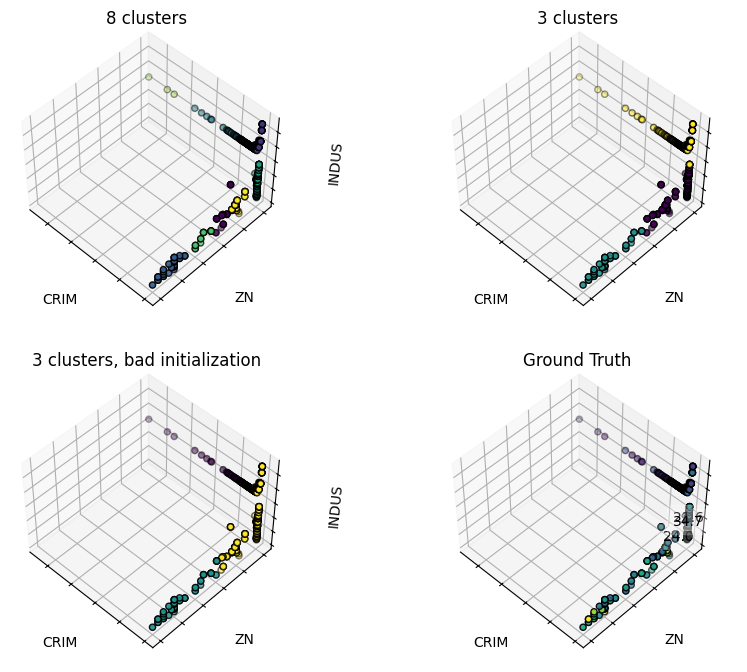

In [8]:
estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8)),
    ("k_means_iris_3", KMeans(n_clusters=3)),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X["CRIM"], X["ZN"], X["INDUS"], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("CRIM")
    ax.set_ylabel("ZN")
    ax.set_zlabel("INDUS")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)
for name, label in [(vals[0], 0), (vals[1], 1), (vals[2], 2)]:
    ds = dataset[dataset["MEDV"]==name]
    ax.text3D(
        ds["CRIM"].mean(),
        ds["ZN"].mean(),
        ds["INDUS"].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X["CRIM"], X["ZN"], X["INDUS"], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("CRIM")
ax.set_ylabel("ZN")
ax.set_zlabel("INDUS")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

Каждый цвет на графиках (кроме последнего) представляет группу (кластер), которую алгоритм K-Means посчитал похожей по признакам. В моем датасете
НЕТ четко разделенных кластеров, данные представляют собой непрерывное распределение домов с разными характеристиками. K-Means пытается найти группы, но они получаются размытыми.

**Оценка силуэта (Silhouette Score):**

In [9]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score


n_clusters = np.arange(2, 21)

In [10]:
best_metric = [0, 10000, 0,[]]

silhouette_score_values = []
adjusted_rand_score_values = []


for n in n_clusters:

    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)


    if score1 < best_metric[1] and score2 > best_metric[2]:
          best_metric[1] = score1
          best_metric[2] = score2
          best_metric[3] = clusterer.cluster_centers_
          best_metric[0] = n

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/l

In [11]:
best_metric

[np.int64(15),
 np.float64(0.5499571026364101),
 0.0073067190600300275,
 array([[ 3.94040741e-01, -3.55271368e-15,  2.39481481e+01],
        [ 3.82660000e-02,  5.62500000e+01,  3.50100000e+00],
        [ 3.79495619e-01,  7.10542736e-15,  9.90676190e+00],
        [ 7.68103667e+01,  0.00000000e+00,  1.81000000e+01],
        [ 2.66555745e-01,  1.88191489e+01,  5.40234043e+00],
        [ 1.47072000e+01, -3.55271368e-15,  1.81000000e+01],
        [ 3.88232000e-02,  7.88000000e+01,  2.68200000e+00],
        [ 7.87684615e-02,  4.23076923e+01,  4.24538462e+00],
        [ 3.49847580e+00, -7.10542736e-15,  1.87434783e+01],
        [ 4.28849600e+01,  0.00000000e+00,  1.81000000e+01],
        [ 1.88440000e-02,  9.30000000e+01,  2.07900000e+00],
        [ 2.34131455e+01,  1.77635684e-15,  1.81000000e+01],
        [ 7.83503448e-02,  2.94137931e+01,  5.70862069e+00],
        [ 8.65225915e+00, -5.32907052e-15,  1.81000000e+01],
        [ 1.67242564e-01, -7.10542736e-15,  4.79871795e+00]])]

Silhouette Score (коэффициент силуэта) - 0.5528 говорит о хорошей структуре кластеров <br>
Adjusted Rand Score (ARI) - 0.0042 значение близко к 0, получается кластеры не соответствуют ценам на дома. Это логично ведь кластеризация ищет группы по признакам (CRIM, ZN, INDUS), а не по ценам <br>
Оптимальное количество кластеров 13

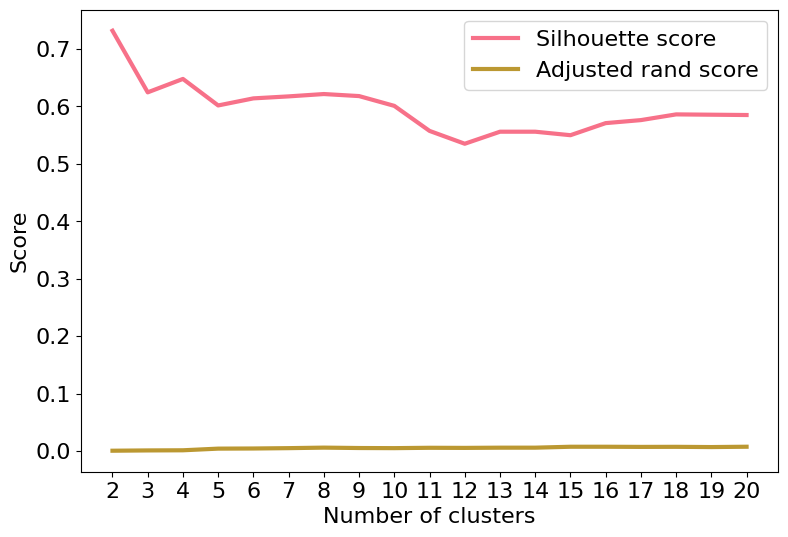

In [12]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()

Silhouette score по графику максимальный при k=2: 0.73<br>
При k=13: 0.55 (гораздо ниже)<br>
ARI везде = 0 (ожидаемо)<br>

#### Иерархическая кластеризация

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram

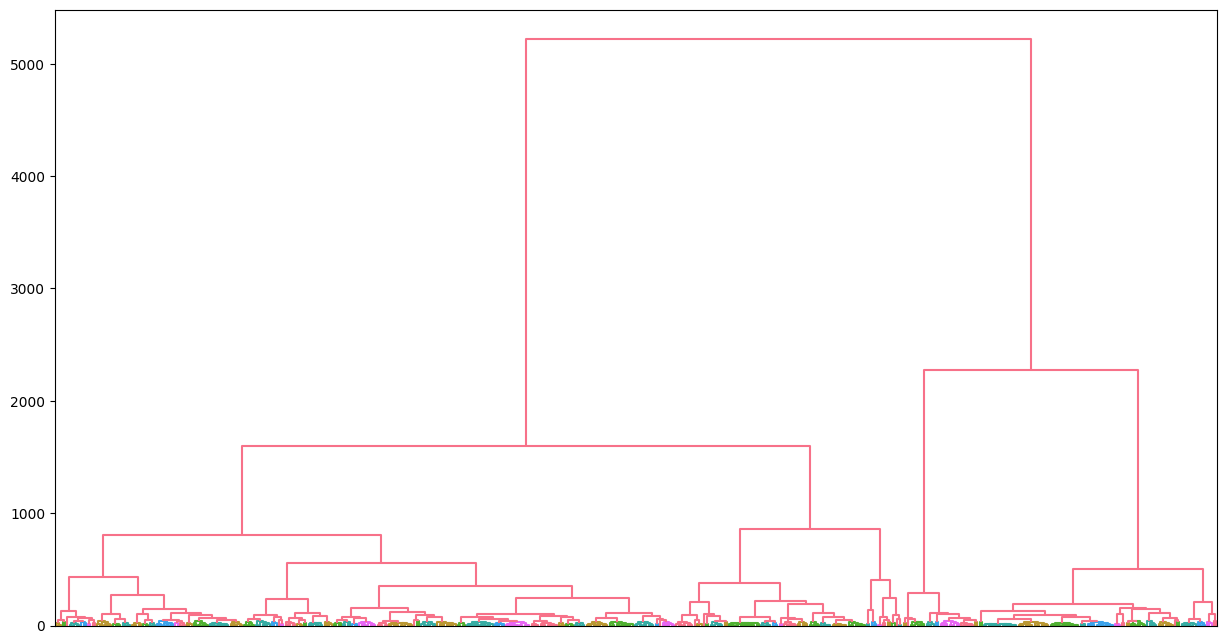

In [14]:
samples = dataset.values

# Реализация иерархической кластеризации при помощи функции linkage
mergings = linkage(samples, method='ward')
# попробуйте с другими методами
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
    labels=list(y),
    leaf_rotation=90,
    leaf_font_size=4,  # Очень мелко
    no_labels=True,  # Вообще без подписей
    color_threshold=40
)



plt.show()

Цены (подписи) группируются - дешевые дома вместе, дорогие вместе, но так как у меня очень много значений, их не видно

#### DBSCAN
***Пространственная кластеризация приложений с шумом на основе плотности***

In [15]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [16]:
mins = X.shape[1]

['y', 'b', 'g', 'r']


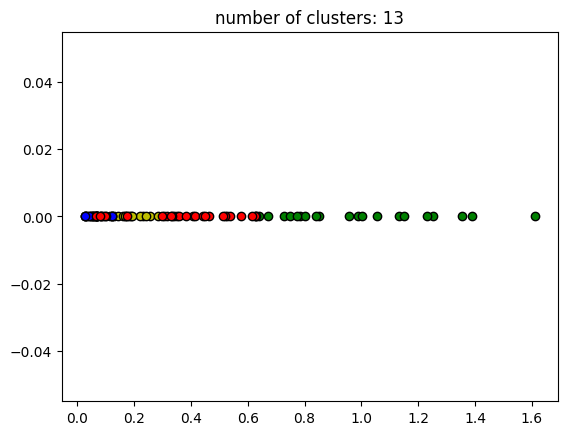

In [17]:
db = DBSCAN(eps=0.5, min_samples=12).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Plot result

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
	if k == -1:
		# Black used for noise.
		col = 'k'

	class_member_mask = (labels == k)

	xy = X[class_member_mask & core_samples_mask]
	plt.plot(xy["CRIM"], xy["ZN"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

	xy = X[class_member_mask & ~core_samples_mask]
	plt.plot(xy["CRIM"], xy["ZN"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

Слева (CRIM 0.0-0.2): Много жёлтых и синих точек
Это районы с низким уровнем преступности
ZN около 0.00 (мало жилой застройки)<br>
В центре (CRIM 0.2-0.8): Зелёные и красные кластеры
Средний уровень преступности<br>
Справа (CRIM 0.8-1.6): Только зеленые точки
Высокий уровень преступности
ZN около 0.00<br>

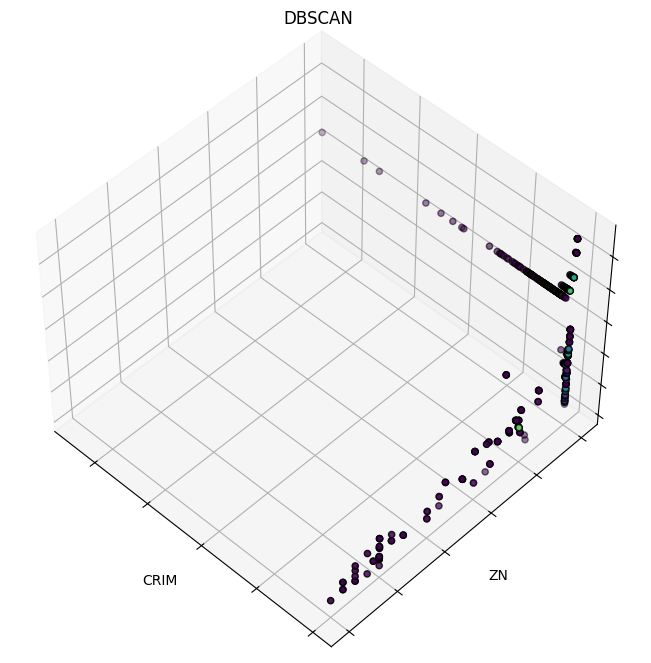

In [19]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter(X["CRIM"], X["ZN"], X["INDUS"], c=labels.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("CRIM")
ax.set_ylabel("ZN")
ax.set_zlabel("INDUS")
ax.set_title("DBSCAN")

plt.show()

Для оценки алгоритмов кластеризации мы будем использовать оценку силуэта и оценку скорректированного рэнда. Оценка Silhouette находится в диапазоне от -1 до 1. Оценка около 1 означает, что точка данных i очень компактна в пределах кластера, к которому она принадлежит, и удалена от других кластеров. Худшее значение — -1. Значения, близкие к 0, обозначают перекрывающиеся кластеры.

Абсолютный показатель Rand Score находится в диапазоне от 0 до 1. Больше 0,9 означает отличное кластерное восстановление, а выше 0,8 — хорошее восстановление. Менее 0,5 считается плохим восстановлением.

In [22]:
# evaluation metrics
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = adjusted_rand_score(y, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.05
Adjusted Rand Index: 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)


Silhouette Score = 0.05 (очень низкий): Кластеры почти не разделены, точки находятся близко к границам между кластерами, очень размытая структура
Кластеры не соответствуют реальным ценам на дома (ARI = 0.00).

Вывод: мой датасет подходит больше для задач регрессии, а не кластеризации

Надо предсказать непрерывное число — цену дома (MEDV)<br>
В данных нет групп — дома распределены непрерывно, нет чётких границ нет